The script plot the waveforms of the stimuli and the waveforms recorded StimTrak of first n tokens receiving the lowest max correlations.

In [2]:
#### libraries ####
import os
import mne

import numpy as np
from scipy import signal
from scipy.io import wavfile
from pybv import write_brainvision
import matplotlib.pyplot as plt
"""
Overview:
1. fixing trigger timing & renaming events
"""

'\nOverview:\n1. fixing trigger timing & renaming events\n'

In [4]:
## parameters
# frequency of the eeg recording for audio downsampling
eeg_freq = 500


# directory
input_dir = os.getcwd() + '/../raw data/eeg_brainvision/'

# create a dictionary for blocks and block markers
block_dict = {
    'dorsal_highStan_lowDevi': 1000, # standard: dorsal_high; deviant: dorsal_low
    'dorsal_lowStan_highDevi': 2000, # standard: dorsal_low; deviant: dorsal_high
    'glottal_highStan_lowDevi': 3000, # standard: glottal_high; deviant: glottal_low
    'glottal_lowStan_highDevi': 4000, # standard: glottal_low; deviant: glottal_high
}

# create a dictionary for trigger codes and descriptions
mapping = {
    1000: "dorsal_highStan_lowDevi-stan",
    1100: "dorsal_highStan_lowDevi-devi",
    2000: "dorsal_lowStan_highDevi-stan",
    2100: "dorsal_lowStan_highDevi-devi",
    3000: "glottal_highStan_lowDevi-stan",
    3100: "glottal_highStan_lowDevi-devi",
    4000: "glottal_lowStan_highDevi-stan",
    4100: "glottal_lowStan_highDevi-devi",
}

# trigger searching window (actual trigger time based on audio - trigger time in the data)
t_left = -0.01
t_right = 0.2

## Trigger Fix
Looping through recordings to fix trigger latency and rename triggers based on groupings that will be used for the analysis

Extracting parameters from /Users/chaohan/Library/CloudStorage/OneDrive-UniversityofToronto/Projects/Laryngeal/scripts/../raw data/eeg_brainvision/CUE2024_0043_F0.vhdr...
Setting channel info structure...
Reading 0 ... 2057639  =      0.000 ...  4115.278 secs...


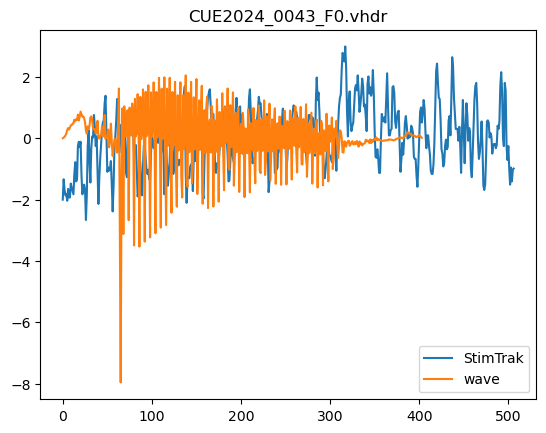

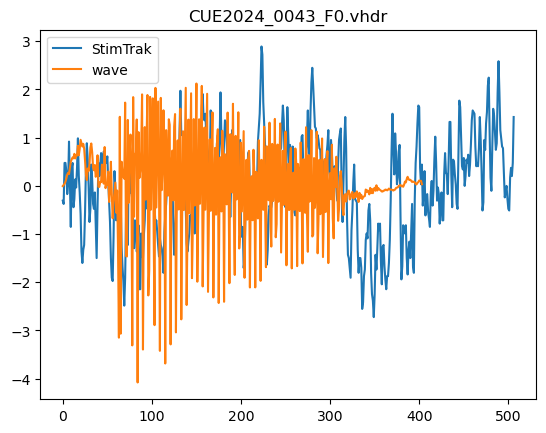

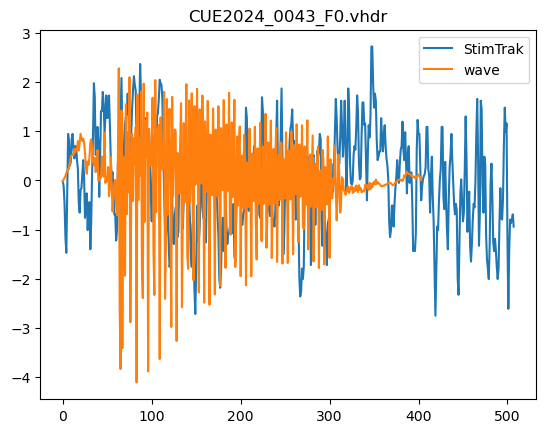

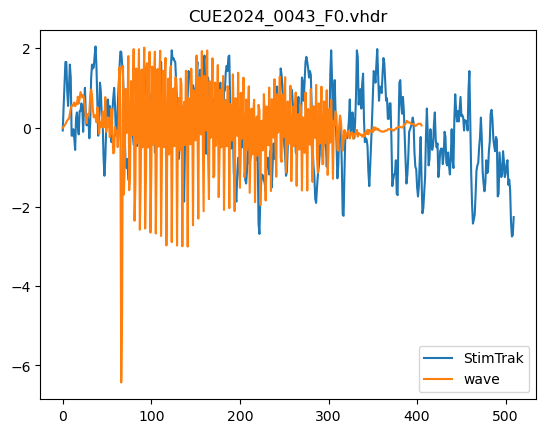

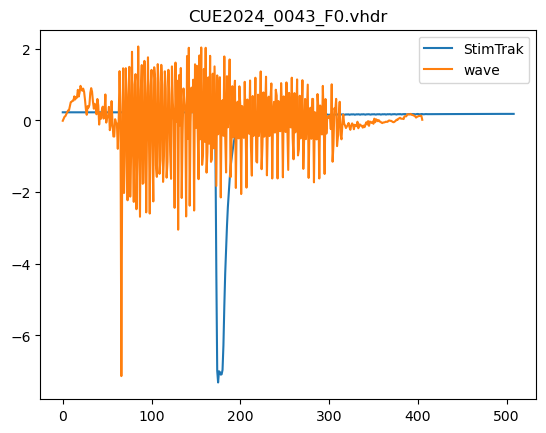

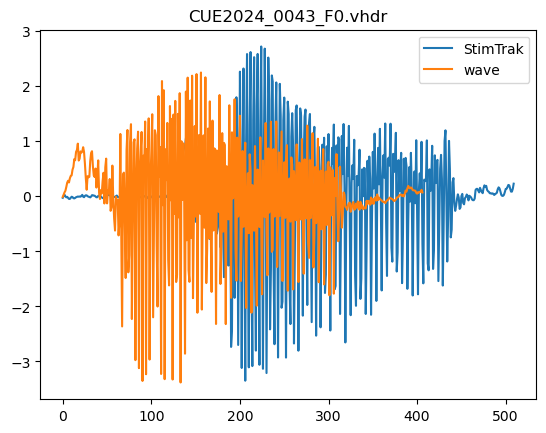

In [6]:
# read in eeg data files
file = 'CUE2024_0043_F0.vhdr'
# look at the first n tokens with 
first_n = 6

# read in vhdr files
raw = mne.io.read_raw_brainvision(input_dir + file, preload = True)

# extract the info of experiment version
exp_ver = file.split('.')[0].split('_')[2]

##########################################################################################
#### create a trigger dictionary for each stim's standard version and deviant version ####
##########################################################################################

# intialize a dictionary for triggers
trigger_dict = {}

# read in trigger_codes file, and create a standard trigger code and a deviant triggre code for each stimulus
with open('../experiment programs/'+exp_ver+'_eeg/trigger_codes.txt','r') as tf:
    for line in tf:
        # read in the current line
        line = line.replace('\n','')
        # separate fileNames and triggerMarker
        label, marker = line.split('\t')
        # convert trigger markers to integer
        marker = int(marker)
        # create label for stims used as standards
        trigger_dict[marker] = label + '-s'
        # add 100 for deviant marker
        marker_deviant = marker + 100
        # create label for stims used as deviants
        trigger_dict[marker_deviant] = label + '-d'

################################
#### downsample audio files ####
################################

# initialize dictionaries
audio = {}
lengths = {}

# del trigger_dict[99999]
# for each trigger code and label in the trigger dictionary
for marker,label in trigger_dict.items():
    # extract file name, up to the -2 character of the label
    file_name = label[:-2]
    # if not already in audio dictionary, get the info of the audio file
    if file_name not in audio:
        # get sample rate and data of the audio file
        sampleRate, data = wavfile.read('../experiment programs/'+exp_ver+'_eeg/stimuli/{}.wav'.format(file_name))
        # calculate sound file length
        lengths[file_name] = len(data)/sampleRate
        # reduce the sampling rate of the audio file by the factor of int(sampleRate/eeg_freq)
        data_downsampled = signal.decimate(data, int(sampleRate/eeg_freq), ftype='fir')
        # add info the audio dictionary
        audio[file_name] = data_downsampled

##########################################
#### trigger correction for each file ####
##########################################

# If the aux channel is not named 'StimTrak', change the channel name to 'StimTrak'
if raw.info['ch_names'][31] != 'StimTrak':
    # change the channel name
    raw.rename_channels({raw.info['ch_names'][31]: 'StimTrak'})
    # specify the audio channel
    raw.set_channel_types({'StimTrak':'misc'})

#### making events ####
# for each stimulus, mark the block info
events_from_annot, event_dict = mne.events_from_annotations(raw, verbose='WARNING')
# remove the New Segment marker (which has a trigger value of 99999) and pause marker (222) and continue marker (223)
events_from_annot = events_from_annot[events_from_annot[:, 2] < 200]

# initialize the train for each standards+deviant sequence
train = np.array([]).astype(int)

all_block = {}
isStandard = True # whether the standard in a train has been noted

# loop over each trigger
for i in range(events_from_annot.shape[0]):
    # add the current token to the train
    train = np.append(train,i)

    # if the trigger value is smaller than 100 and the standard toggle is true
    if (events_from_annot[i,2]<100) & isStandard:
        # split the file name
        trigger_splitted = trigger_dict[events_from_annot[i,2]].split('_')
        # get the standard category name
        block = trigger_splitted[1] + '_' + trigger_splitted[2] + 'Stan'
        # toggle standard
        isStandard = False

    # if the trigger value is over 100
    elif events_from_annot[i,2]>100:
        # split the file name
        trigger_splitted = trigger_dict[events_from_annot[i,2]].split('_')
        # append the deviant stim category 
        block = block + '_' + trigger_splitted[2] + 'Devi'

        # if the block is not present in all block
        if block not in all_block:
            # add the new block and the token idx
            all_block[block] = train[2:] # [2:] to exclude the first 2 standards
        else:
            # add the token idx to the existing block
            all_block[block] = np.concatenate([all_block[block],train[2:]],axis = None)

        # reset train
        train = np.array([]).astype(int)

        # toggle standard note
        isStandard = True

# loop over each block and its trigger index
for k,v in all_block.items():
    # recode the trigger value to reflect block and stim category
    events_from_annot[tuple(v),2] += block_dict[k]

# exclude the first 2 standards
events_from_annot = events_from_annot[events_from_annot[:,2]>1000]

########################################################
#### calculate cross correction to detect the delay ####
########################################################

# initialize delay list
delays = np.array([])
# initialize bad stim list
bad_stim = []
corr_results = []

# loop over each event
for i in range(events_from_annot.shape[0]):

    # get current event info [time, duration, annotation]
    event = events_from_annot[i]
    # get the onset latency (s) of the event
    time = event[0]/raw.info['sfreq']
    # get the file name of the event
    name = trigger_dict[event[2]%100].split('-')[0]
    # get the data from the sound channel
    audio_eeg = raw.get_data(
        picks = ['StimTrak'],
        tmin = time + t_left,
        tmax = time + lengths[name] + t_right,
    )[0]

    # Z-score normalization (subtract mean, divide by std)
    audio_eeg = (audio_eeg - np.mean(audio_eeg)) / np.std(audio_eeg)
    audio[name] = (audio[name] - np.mean(audio[name])) / np.std(audio[name])
    
    # cross-correlation
    corr = signal.correlate(audio_eeg, audio[name], mode='full')
    # Normalize cross-correlation
    corr = corr / (np.linalg.norm(audio_eeg) * np.linalg.norm(audio[name]))
    # Find peak correlation value
    max_corr = np.max(corr)            

    # append the maximum correlation
    corr_results.append(max_corr)

    
    # the lags for cross-correlation
    lags = signal.correlation_lags(
        audio_eeg.size,
        audio[name].size,
        mode="full")
    # get the lag of the maximum cross-correlation
    lag = lags[np.argmax(corr)] + t_left*raw.info['sfreq']
    
    # save the lag for non-starting events
    delays = np.append(delays,lag)

#############
# plot the wave from the stim track and the eeg channel of the token with the minimum corr #
#############

# Sort numbers while keeping track of indices
indexed_numbers = sorted(enumerate(corr_results), key=lambda x: x[1])

# Get the first 10 smallest numbers with their original indices
smallest_numbers_with_indices = indexed_numbers[:first_n]

for small_i in smallest_numbers_with_indices:
    # get current event info [time, duration, annotation]
    event = events_from_annot[small_i[0]]
    # get the onset latency (s) of the event
    time = event[0]/raw.info['sfreq']
    # get the file name of the event
    name = trigger_dict[event[2]%100].split('-')[0]
    # get the data from the sound channel
    audio_eeg = raw.get_data(
        picks = ['StimTrak'],
        tmin = time + t_left,
        tmax = time + lengths[name] + t_right,
    )[0]
    
    # Z-score normalization (subtract mean, divide by std)
    audio_eeg = (audio_eeg - np.mean(audio_eeg)) / np.std(audio_eeg)
    audio[name] = (audio[name] - np.mean(audio[name])) / np.std(audio[name])
    
    fig, ax = plt.subplots()
    ax.plot(audio_eeg, label = 'StimTrak')
    ax.plot(audio[name], label = 'wave')
    ax.set_title(file)
    ax.legend()
    plt.show()
##########################

In [28]:
np.sort(corr_results)[0:50]

array([0.05758215, 0.05893143, 0.06150496, 0.06360447, 0.06703932,
       0.06741837, 0.08547843, 0.08557696, 0.56166553, 0.56239547,
       0.56430091, 0.56458398, 0.56482713, 0.56513753, 0.56582239,
       0.56647779, 0.56738   , 0.56959752, 0.56973064, 0.56974875,
       0.56995807, 0.57016699, 0.57128073, 0.57163496, 0.57303283,
       0.5738297 , 0.57412338, 0.5745471 , 0.57562165, 0.57664955,
       0.57766527, 0.57774428, 0.57815602, 0.57843705, 0.57929303,
       0.57962352, 0.58010578, 0.58040944, 0.58082533, 0.58136191,
       0.58141583, 0.58328991, 0.58419832, 0.58482447, 0.58557124,
       0.58573236, 0.58616783, 0.58669   , 0.58698155, 0.58794323])